# Day 4 - Fund Performance Analytics

### Import Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data' / 'processed'
CHART_DIR = ROOT / 'reports' / 'charts'
RF_ANNUAL = 0.065
RF_DAILY = RF_ANNUAL / 252
TRADING_DAYS = 252
sns.set_theme(style='whitegrid')

### Load Datasets

In [2]:
nav = pd.read_csv(DATA_DIR / 'nav_history_clean.csv')
benchmark = pd.read_csv(DATA_DIR / 'benchmark_indices_clean.csv')
fund_master = pd.read_csv(DATA_DIR / 'fund_master_clean.csv')

nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
benchmark = benchmark.sort_values(['index_name', 'date']).reset_index(drop=True)

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
benchmark['benchmark_return'] = benchmark.groupby('index_name')['close_value'].pct_change()

print('Schemes:', nav['amfi_code'].nunique())
print('NAV rows:', len(nav))
nav.head()

Schemes: 40
NAV rows: 46000


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


### daily returns

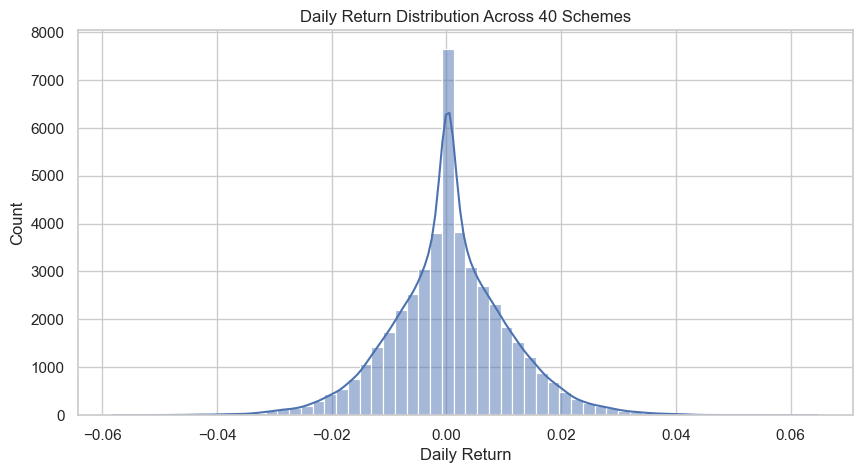

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
1%          -0.025982
5%          -0.016254
50%          0.000340
95%          0.017842
99%          0.027617
max          0.064713
Name: daily_return, dtype: float64

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(nav['daily_return'].dropna(), bins=60, kde=True)
plt.title('Daily Return Distribution Across 40 Schemes')
plt.xlabel('Daily Return')
plt.show()

nav['daily_return'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

### CAGR for 1yr, 3yr, 5yr

In [4]:
def cagr_for_window(fund, years):
    min_rows = years * TRADING_DAYS
    if len(fund.dropna(subset=['nav'])) < min_rows:
        return np.nan
    end_date = fund['date'].max()
    start_cutoff = end_date - pd.DateOffset(years=years)
    window = fund[fund['date'] >= start_cutoff].dropna(subset=['nav'])
    if len(window) < min_rows:
        return np.nan
    actual_years = (window.iloc[-1]['date'] - window.iloc[0]['date']).days / 365.25
    return (window.iloc[-1]['nav'] / window.iloc[0]['nav']) ** (1 / actual_years) - 1

cagr_df = pd.DataFrame([
    {
        'amfi_code': code,
        'cagr_1yr': cagr_for_window(fund, 1),
        'cagr_3yr': cagr_for_window(fund, 3),
        'cagr_5yr': cagr_for_window(fund, 5),
    }
    for code, fund in nav.groupby('amfi_code')
])
cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022258,0.012924,NaN
1,100025,0.037076,0.039155,NaN
2,100033,0.532772,0.324340,NaN
3,101206,0.479638,0.289602,NaN
4,101207,-0.240003,-0.041515,NaN


### Sharpe Ratio & Sortino Ratio

In [11]:
risk_rows = []
for code, fund in nav.groupby('amfi_code'):
    r = fund['daily_return'].dropna()
    excess = r - RF_DAILY
    downside = r[r < 0]
    sharpe = excess.mean() / r.std() * np.sqrt(TRADING_DAYS)
    sortino = excess.mean() / downside.std() * np.sqrt(TRADING_DAYS)
    risk_rows.append({'amfi_code': code, 'sharpe_ratio': sharpe, 'sortino_ratio': sortino})

risk_df = pd.DataFrame(risk_rows)
risk_df.sort_values('sharpe_ratio', ascending=False).head()

,amfi_code,sharpe_ratio,sortino_ratio
34,148567,1.448291,2.385644
30,120843,1.306744,2.364320
36,148569,1.234930,2.146914
19,119551,1.208267,2.140267
25,120505,1.180101,2.029353


### Alpha and Beta

In [6]:
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'][['date', 'benchmark_return']].dropna()
alpha_beta_rows = []
for code, fund in nav.groupby('amfi_code'):
    merged = fund[['date', 'daily_return']].merge(nifty100, on='date').dropna()
    regression = linregress(merged['benchmark_return'], merged['daily_return'])
    alpha_beta_rows.append({
        'amfi_code': code,
        'alpha': regression.intercept * TRADING_DAYS,
        'beta': regression.slope,
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows)
alpha_beta_df.to_csv(DATA_DIR / 'alpha_beta.csv', index=False)
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


### Maximum Drawdown

In [7]:
dd_rows = []
for code, fund in nav.groupby('amfi_code'):
    fund = fund.copy()
    fund['running_max'] = fund['nav'].cummax()
    fund['drawdown'] = fund['nav'] / fund['running_max'] - 1
    trough_idx = fund['drawdown'].idxmin()
    peak_idx = fund.loc[:trough_idx, 'nav'].idxmax()
    dd_rows.append({
        'amfi_code': code,
        'max_drawdown': fund.loc[trough_idx, 'drawdown'],
        'drawdown_start_date': fund.loc[peak_idx, 'date'].date().isoformat(),
        'drawdown_end_date': fund.loc[trough_idx, 'date'].date().isoformat(),
    })

dd_df = pd.DataFrame(dd_rows)
dd_df.sort_values('max_drawdown').head()

,amfi_code,max_drawdown,drawdown_start_date,drawdown_end_date
22,119599,-0.525742,2023-01-17,2025-10-28
17,119095,-0.516778,2025-05-22,2026-05-11
4,101207,-0.354469,2024-11-21,2026-05-11
39,149324,-0.311719,2024-05-03,2025-01-03
21,119598,-0.287060,2024-08-28,2025-05-14


In [8]:
tracking_rows = []
for code, fund in nav.groupby('amfi_code'):
    merged = fund[['date', 'daily_return']].merge(nifty100, on='date').dropna()
    tracking_error = (merged['daily_return'] - merged['benchmark_return']).std() * np.sqrt(TRADING_DAYS)
    tracking_rows.append({'amfi_code': code, 'tracking_error': tracking_error})

tracking_error_df = pd.DataFrame(tracking_rows)
tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


### Fund Scorecard 

In [9]:
def percentile_rank(series, higher_is_better=True):
    values = series if higher_is_better else -series
    return values.rank(pct=True, na_option='bottom')

expense_df = fund_master[['amfi_code', 'scheme_name', 'expense_ratio_pct']]
scorecard = (
    cagr_df.merge(risk_df, on='amfi_code')
    .merge(alpha_beta_df, on='amfi_code')
    .merge(dd_df, on='amfi_code')
    .merge(tracking_error_df, on='amfi_code')
    .merge(expense_df, on='amfi_code', how='left')
)

scorecard['return_rank'] = percentile_rank(scorecard['cagr_3yr'], True)
scorecard['sharpe_rank'] = percentile_rank(scorecard['sharpe_ratio'], True)
scorecard['alpha_rank'] = percentile_rank(scorecard['alpha'], True)
scorecard['expense_rank'] = percentile_rank(scorecard['expense_ratio_pct'], False)
scorecard['dd_rank'] = percentile_rank(scorecard['max_drawdown'], True)

scorecard['fund_score'] = (
    scorecard['return_rank'] * 30
    + scorecard['sharpe_rank'] * 25
    + scorecard['alpha_rank'] * 20
    + scorecard['expense_rank'] * 15
    + scorecard['dd_rank'] * 10
)

scorecard = scorecard[[
    'amfi_code', 'scheme_name', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr',
    'sharpe_ratio', 'sortino_ratio', 'alpha', 'beta', 'max_drawdown',
    'drawdown_start_date', 'drawdown_end_date', 'expense_ratio_pct',
    'tracking_error', 'return_rank', 'sharpe_rank', 'alpha_rank',
    'expense_rank', 'dd_rank', 'fund_score'
]].sort_values('fund_score', ascending=False)

scorecard.to_csv(DATA_DIR / 'fund_scorecard.csv', index=False)
scorecard.head()

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,drawdown_start_date,drawdown_end_date,expense_ratio_pct,tracking_error,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.203760,0.339920,NaN,1.448291,2.385644,0.269838,0.023684,-0.112657,2023-07-11,2023-10-20,1.46,0.189664,0.975,1.000,0.850,0.450,0.825,86.25
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.296277,0.317692,NaN,1.180101,2.029353,0.292636,0.000549,-0.181885,2024-10-24,2025-01-23,1.36,0.231968,0.900,0.900,0.950,0.650,0.400,82.25
30,120843,Kotak Flexicap Fund - Regular - Growth,0.266776,0.295751,NaN,1.306744,2.364320,0.273305,-0.022830,-0.129740,2022-03-07,2022-04-13,1.45,0.206425,0.850,0.975,0.900,0.475,0.700,82.00
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324340,NaN,1.093699,1.829134,0.271954,0.005104,-0.162172,2022-03-11,2022-05-12,1.38,0.228699,0.925,0.850,0.875,0.600,0.525,80.75
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.130738,0.324789,NaN,1.026524,1.805294,0.211948,0.016232,-0.125883,2022-10-04,2023-05-30,0.80,0.191587,0.950,0.775,0.700,0.725,0.725,80.00


### Benchmark comparison chart

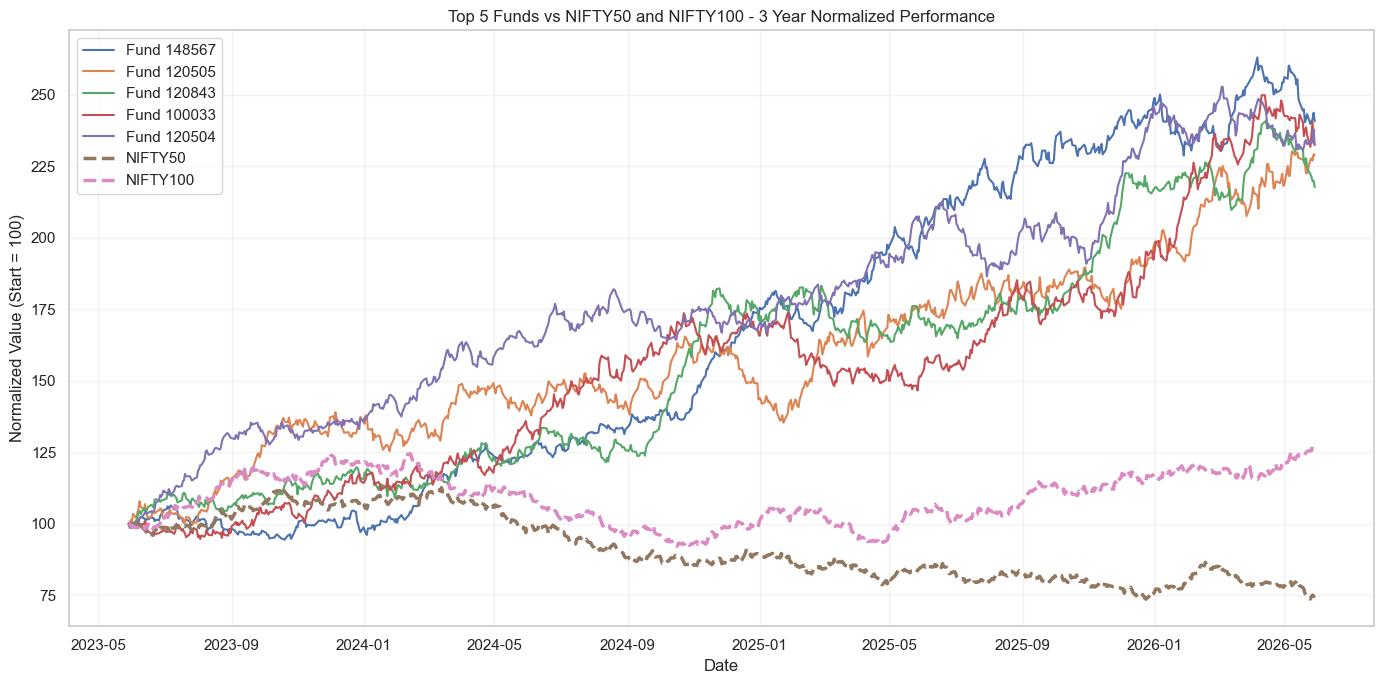

In [10]:
end_date = nav['date'].max()
start_date = end_date - pd.DateOffset(years=3)
top5_codes = scorecard.head(5)['amfi_code'].tolist()

plt.figure(figsize=(14, 7))
for code in top5_codes:
    fund = nav[(nav['amfi_code'] == code) & (nav['date'] >= start_date)].copy()
    fund['normalized_value'] = fund['nav'] / fund['nav'].iloc[0] * 100
    plt.plot(fund['date'], fund['normalized_value'], label=f'Fund {code}')

for index_name in ['NIFTY50', 'NIFTY100']:
    index_df = benchmark[(benchmark['index_name'] == index_name) & (benchmark['date'] >= start_date)].copy()
    index_df['normalized_value'] = index_df['close_value'] / index_df['close_value'].iloc[0] * 100
    plt.plot(index_df['date'], index_df['normalized_value'], linestyle='--', linewidth=2.5, label=index_name)

plt.title('Top 5 Funds vs NIFTY50 and NIFTY100 - 3 Year Normalized Performance')
plt.xlabel('Date')
plt.ylabel('Normalized Value (Start = 100)')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(CHART_DIR / 'benchmark_comparison.png', dpi=150)
plt.show()